# Determinants of Housing Rental Prices in Seoul: Applying Explainable AI

This repository contains the source code and Jupyter Notebooks used for the experiments presented in the following publication.

---

## 📄 Paper Information

**Title**  
*Determinants of Housing Rental Prices in Seoul: Applying Explainable AI*

**Authors**  
Tae-Young Kim, Eunil Park, and Doojin Ryu

**Publication**  
Kim, T.-Y., Park, E., & Ryu, D. (2025). *Determinants of housing rental prices in Seoul: applying explainable AI*. **Spatial Economic Analysis**, **20**(2), 312–332.

**DOI**  
https://doi.org/10.1080/17421772.2024.2418906

---

## 📚 Citation

If you use this repository or refer to the methodology presented in the paper, please cite:

> Kim, T.-Y., Park, E., & Ryu, D. (2025). *Determinants of housing rental prices in Seoul: applying explainable AI*. **Spatial Economic Analysis**, **20**(2), 312–332. https://doi.org/10.1080/17421772.2024.2418906

---

## 🔍 Overview

This repository contains the Jupyter Notebooks used to reproduce the experiments presented in the paper. The notebooks follow the workflow described below.

---

## 📂 Workflow

### 1. Read Data
- Load the Seoul housing rental price dataset.

### 2. Data Preprocessing
- Correlation analysis and correlation plot
- Label encoding of categorical variables

### 3. Modeling
The following machine learning models are implemented and compared:

- Linear Regression (LM)
- Decision Tree (DT)
- LightGBM (LGB)
- Random Forest (RF)
- XGBoost

### 4. Explainable AI
- TreeSHAP analysis
- Visualization and interpretation of feature importance

---

The repository is intended to facilitate the reproducibility and transparency of the experimental results reported in the paper.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
import sklearn.metrics
from sklearn.model_selection import train_test_split 
from ray.tune.schedulers import ASHAScheduler
import xgboost as xgb
import ray
from ray import tune
from ray.tune.integration.xgboost import TuneReportCheckpointCallback
import matplotlib.pyplot as plt
import seaborn as sns
import shap 

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score


import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

 
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Darwin': 
        plt.rc('font', family='AppleGothic') 
elif platform.system() == 'Windows':
        plt.rc('font', family='D2Coding')  
plt.rc('axes',unicode_minus=False)
pd.set_option('display.max_columns', None)

### 1. Read Data

- Load the `seoul_apt_data` dataset.
- Divide the dataset into training and test sets to ensure unbiased model evaluation.

In [2]:
data = pd.read_csv("seoul_apt_data.csv")

In [3]:
data.shape

(557859, 37)

In [5]:
from sklearn.model_selection import train_test_split 
y = data.PRSQM
X = data.drop('PRSQM', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1, random_state=42)

In [6]:
print('train : ',len(y_train),',test : ', len(y_test))

train :  502073 ,test :  55786


### 2. Data Preprocessing

- Standardize all continuous variables while excluding categorical variables.
- Generate two correlation plots for the continuous variables:
  - **Full correlation matrix**.
  - **Filtered correlation matrix** including only variable pairs with an absolute correlation coefficient (|r|) greater than or equal to **0.2**.
- The filtered correlation plot is presented as **Figure 3** in the published paper.
- Apply label encoding to categorical variables.
- Apply label encoding to all categorical variables before model training.

In [7]:
X_train_conti = X_train.drop(['codeHallNm','kaptBcompany','kaptdWtimebus','kaptdWtimesub'], axis=1)
X_test_conti = X_test.drop(['codeHallNm','kaptBcompany','kaptdWtimebus','kaptdWtimesub'], axis=1)
scaler = StandardScaler()
X_train_conti_scaled = pd.DataFrame(scaler.fit_transform(X_train_conti), columns = X_train_conti.columns)
X_test_conti_scaled = pd.DataFrame(scaler.transform(X_test_conti), columns = X_test_conti.columns)
scaler_df = pd.concat([y,X_test_conti_scaled],axis=1)


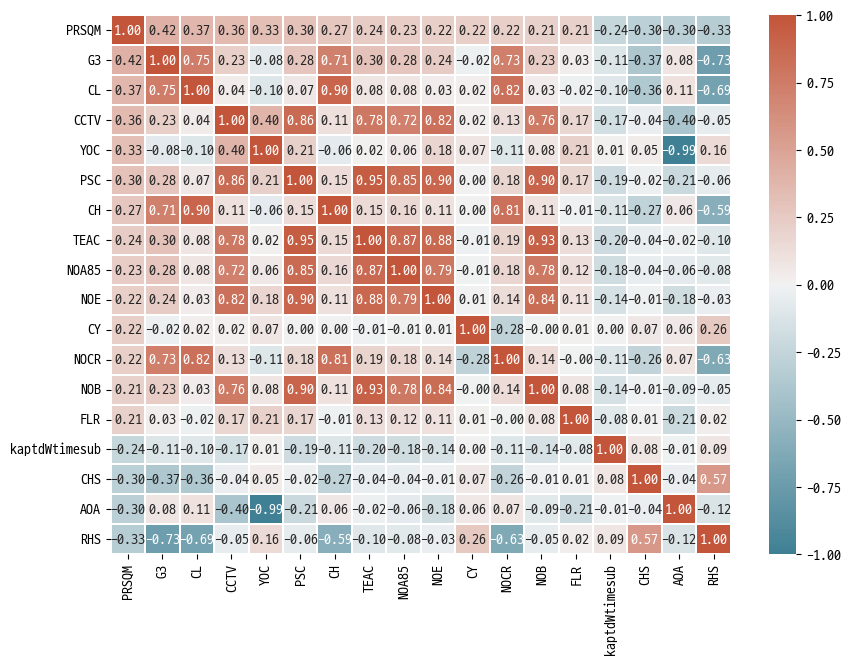

In [8]:
cor_df = data.corr(method='pearson')
cor_df_sort_index = cor_df['PRSQM'].sort_values(ascending=False).index.values
data_df_sort = data[cor_df_sort_index]
cor_df2 = data_df_sort.corr(method='pearson')
cor_df_sort_index_over_02 = cor_df2['PRSQM'][cor_df2['PRSQM'].abs() > 0.2].index.values
data_df_sort_over_02 = data[cor_df_sort_index_over_02]
cor_df2_over_02  = data_df_sort_over_02.corr(method='pearson')
plt.figure(figsize=(10,7))
# sns.heatmap(cor_df2, annot=True, fmt=".2f", linewidth=.3,
#             vmin=-1, vmax=1, center=0,
#             cmap=sns.diverging_palette(220, 20, as_cmap=True))
sns.heatmap(cor_df2_over_02, linewidth=.3,annot=True, fmt=".2f", 
            vmin=-1, vmax=1, center=0,
            cmap=sns.diverging_palette(220, 20, as_cmap=True))
plt.show()

In [9]:
data.describe().transpose()
# data.describe().transpose().to_csv("2_contivar_describe_230901.csv", index=True, encoding="utf-8-sig")

,count,mean,std,min,25%,50%,75%,max
FLR,557859.0,9.464539,6.241362,-4.000000,5.000000,9.000000,13.000000,68.000000
YOC,557723.0,2000.958931,11.037978,1971.000000,1993.000000,2000.000000,2009.000000,2023.000000
PRSQM,557859.0,651.943910,296.035146,10.088781,460.048426,599.036333,778.577327,3625.021931
NOB,557828.0,14.362142,15.948354,1.000000,5.000000,9.000000,17.000000,122.000000
NOA135,557859.0,199.284565,339.129070,0.000000,0.000000,56.000000,264.000000,2728.000000
NOA136,557859.0,48.070937,181.769354,0.000000,0.000000,0.000000,0.000000,2094.000000
NOA60,557859.0,469.004768,579.282562,0.000000,68.000000,267.000000,660.000000,3930.000000
NOA85,557859.0,561.890931,842.644148,0.000000,103.000000,317.000000,655.000000,5132.000000
NOH,557859.0,1278.251201,1359.954062,19.000000,449.000000,844.000000,1588.000000,9510.000000
TEAC,557835.0,100518.954586,116076.307598,2296.310000,32676.600000,62938.800000,117871.910000,734780.750000


#### label encoding

In [10]:
data = data.dropna(subset=['kaptBcompany']).reset_index(drop=True)
data = data.dropna(subset=['codeHallNm']).reset_index(drop=True)
data = data.dropna(subset=['kaptdWtimebus']).reset_index(drop=True)
data = data.dropna(subset=['kaptdWtimesub']).reset_index(drop=True)

data.kaptdWtimebus = data.kaptdWtimebus.astype(int).astype(object)
data.kaptdWtimesub = data.kaptdWtimesub.astype(int).astype(object)

In [11]:
y = data.PRSQM
X = data.drop('PRSQM', axis = 1)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1, random_state=42)

In [13]:
# category_order = ['BUS_less5', 'BUS_5to10', 'BUS_10to15', 'BUS_15to20', 'BUS_over20']
#category_order = ['1','2','3','4','5']
category_order = [1,2,3,4,5]
X_train['kaptdWtimebus'] = pd.Categorical(X_train['kaptdWtimebus'], categories=category_order, ordered=True)
X_test['kaptdWtimebus'] = pd.Categorical(X_test['kaptdWtimebus'], categories=category_order, ordered=True)

# category_order = ['SUB_less5', 'SUB_5to10', 'SUB_10to15', 'SUB_15to20', 'SUB_over20']
X_train['kaptdWtimesub'] = pd.Categorical(X_train['kaptdWtimesub'], categories=category_order, ordered=True)
X_test['kaptdWtimesub'] = pd.Categorical(X_test['kaptdWtimesub'], categories=category_order, ordered=True)


In [ ]:
# Label Encoding
label_encoder_bus = LabelEncoder()
X_train['kaptdWtimebus'] = label_encoder_bus.fit_transform(X_train['kaptdWtimebus'])
X_test['kaptdWtimebus'] = label_encoder_bus.transform(X_test['kaptdWtimebus'])

label_encoder_sub = LabelEncoder()
X_train['kaptdWtimesub'] = label_encoder_sub.fit_transform(X_train['kaptdWtimesub'])
X_test['kaptdWtimesub'] = label_encoder_sub.transform(X_test['kaptdWtimesub'])    

In [15]:
label_encoder_bus.classes_

array([1, 2, 3, 4, 5], dtype=int64)

In [16]:
print("Bus Label Encoding Mapping:")
for i, category in enumerate(label_encoder_bus.classes_):
    print(f"{category} -> {i}")

print("Subway Label Encoding Mapping:")
for i, category in enumerate(label_encoder_sub.classes_):
    print(f"{category} -> {i}")

Bus Label Encoding Mapping:
1 -> 0
2 -> 1
3 -> 2
4 -> 3
5 -> 4
Subway Label Encoding Mapping:
1 -> 0
2 -> 1
3 -> 2
4 -> 3
5 -> 4


In [ ]:
# One-Hot Encoding lists
one_hot_encoded_columns = ['kaptBcompany', 'codeHallNm']

# One-Hot Encoding
one_hot_encoder = OneHotEncoder(sparse=False, drop='if_binary', handle_unknown='error')  # drop='first'는 더미 변수 함정을 피하기 위해 첫 번째 열을 삭제합니다.
one_hot_encoded_data = one_hot_encoder.fit_transform(X_train[one_hot_encoded_columns])

onehot_names = one_hot_encoder.get_feature_names_out()
for i in range(len(onehot_names)):
    onehot_names[i] = onehot_names[i].replace("Onehot__", "")
    onehot_names[i] = onehot_names[i].replace("kaptBcompany_", "")
    onehot_names[i] = onehot_names[i].replace("codeHallNm_", "")
    onehot_names[i] = onehot_names[i].replace("remainder__", "")

one_hot_encoded_data = one_hot_encoder.fit_transform(X_train[one_hot_encoded_columns])
one_hot_encoded_df = pd.DataFrame(one_hot_encoded_data, columns=one_hot_encoder.get_feature_names_out(one_hot_encoded_columns))
one_hot_encoded_df.columns = onehot_names

one_hot_encoded_data_test = one_hot_encoder.transform(X_test[one_hot_encoded_columns])
one_hot_encoded_df_test = pd.DataFrame(one_hot_encoded_data_test, columns=one_hot_encoder.get_feature_names_out(one_hot_encoded_columns))
one_hot_encoded_df_test.columns = onehot_names


# One-Hot encoding index delete from Origianl DataFrame 
X_train = X_train.drop(columns=one_hot_encoded_columns).reset_index(drop=True)
X_test = X_test.drop(columns=one_hot_encoded_columns).reset_index(drop=True)


# Merge the encoded variables with the original dataset.
X_train = pd.concat([X_train, one_hot_encoded_df], axis=1)
X_test = pd.concat([X_test, one_hot_encoded_df_test], axis=1)

# List of continuous variables to be standardized using StandardScaler.
continuous_columns = ['FLR', 'YOC', 'NOB', 'NOA135', 'NOA136', 'NOA60', 'NOA85', 'NOH',
                      'TEAC', 'NOE', 'CCTV', 'PNP', 'NOP', 'PNP', 'ELS', 'MLS', 'HSS', 'PSC',
                      'NOCR', 'RHS', 'SHS', 'VHS', 'CHS', 'GH', 'CH', 'CL', 'TP', 'PPH',
                      'ELD', 'AOA', 'CY', 'G3']

# StandardScaler
scaler = StandardScaler()
X_train[continuous_columns] = scaler.fit_transform(X_train[continuous_columns])
X_test[continuous_columns] = scaler.transform(X_test[continuous_columns])

In [18]:
X_train.rename(columns = {'kaptdWtimebus':'BUS'}, inplace = True)
X_train.rename(columns = {'kaptdWtimesub':'SUBWAY'}, inplace = True)

X_test.rename(columns = {'kaptdWtimebus':'BUS'}, inplace = True)
X_test.rename(columns = {'kaptdWtimesub':'SUBWAY'}, inplace = True)

In [19]:
X_train.BUS.unique()

array([1, 0, 2, 3, 4], dtype=int64)

### 3. Modeling

This section implements the following machine learning models:

- Linear Regression (LM)
- Decision Tree (DT)
- Random Forest (RF)
- LightGBM (LGB)
- XGBoost

#### 10-Fold Cross-Validation

The notebook includes code for **10-fold cross-validation** using all five models listed above.

> **Note:** The cross-validation code is computationally expensive and may take a considerable amount of time to run. Therefore, it is **commented out by default**. If you would like to reproduce the cross-validation results, simply **uncomment the relevant code blocks** before execution.

#### Standard Model Training

In addition to the cross-validation implementation, the notebook also includes **standard model training and evaluation code (without cross-validation)**, which can be executed directly.

In [ ]:
# CV_results = pd.DataFrame(columns=['lm','dt','rf','lgb','xgboost'])

In [ ]:
# for i in range(5):
#     print('iteration :'+str(i)+'/10')
#     X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1)
#     category_order = ['BUS_less5', 'BUS_5to10', 'BUS_10to15', 'BUS_15to20', 'BUS_over20']
#     X_train['kaptdWtimebus'] = pd.Categorical(X_train['kaptdWtimebus'], categories=category_order, ordered=True)
#     X_test['kaptdWtimebus'] = pd.Categorical(X_test['kaptdWtimebus'], categories=category_order, ordered=True)

#     category_order = ['SUB_less5', 'SUB_5to10', 'SUB_10to15', 'SUB_15to20', 'SUB_over20']
#     X_train['kaptdWtimesub'] = pd.Categorical(X_train['kaptdWtimesub'], categories=category_order, ordered=True)
#     X_test['kaptdWtimesub'] = pd.Categorical(X_test['kaptdWtimesub'], categories=category_order, ordered=True)


#     # Label Encoding 
#     label_encoder_bus = LabelEncoder()
#     X_train['kaptdWtimebus'] = label_encoder_bus.fit_transform(X_train['kaptdWtimebus'])
#     X_test['kaptdWtimebus'] = label_encoder_bus.transform(X_test['kaptdWtimebus'])

#     label_encoder_sub = LabelEncoder()
#     X_train['kaptdWtimesub'] = label_encoder_sub.fit_transform(X_train['kaptdWtimesub'])
#     X_test['kaptdWtimesub'] = label_encoder_sub.transform(X_test['kaptdWtimesub'])    

#     # One-Hot Encoding Lists
#     one_hot_encoded_columns = ['kaptBcompany', 'codeHallNm']

#     # One-Hot Encoding 
#     one_hot_encoder = OneHotEncoder(sparse=False, drop='if_binary', handle_unknown='error')  # drop='first'는 더미 변수 함정을 피하기 위해 첫 번째 열을 삭제합니다.
#     one_hot_encoded_data = one_hot_encoder.fit_transform(X_train[one_hot_encoded_columns])

#     onehot_names = one_hot_encoder.get_feature_names_out()
#     for i in range(len(onehot_names)):
#         onehot_names[i] = onehot_names[i].replace("Onehot__", "")
#         onehot_names[i] = onehot_names[i].replace("kaptBcompany_", "")
#         onehot_names[i] = onehot_names[i].replace("codeHallNm_", "")
#         onehot_names[i] = onehot_names[i].replace("remainder__", "")

#     one_hot_encoded_data = one_hot_encoder.fit_transform(X_train[one_hot_encoded_columns])
#     one_hot_encoded_df = pd.DataFrame(one_hot_encoded_data, columns=one_hot_encoder.get_feature_names_out(one_hot_encoded_columns))
#     one_hot_encoded_df.columns = onehot_names

#     one_hot_encoded_data_test = one_hot_encoder.transform(X_test[one_hot_encoded_columns])
#     one_hot_encoded_df_test = pd.DataFrame(one_hot_encoded_data_test, columns=one_hot_encoder.get_feature_names_out(one_hot_encoded_columns))
#     one_hot_encoded_df_test.columns = onehot_names


#     X_train = X_train.drop(columns=one_hot_encoded_columns).reset_index(drop=True)
#     X_test = X_test.drop(columns=one_hot_encoded_columns).reset_index(drop=True)


#     X_train = pd.concat([X_train, one_hot_encoded_df], axis=1)
#     X_test = pd.concat([X_test, one_hot_encoded_df_test], axis=1)

#     continuous_columns = ['FLR', 'YOC', 'NOB', 'NOA135', 'NOA136', 'NOA60', 'NOA85', 'NOH',
#                           'TEAC', 'NOE', 'CCTV', 'PNP', 'NOP', 'PNP', 'ELS', 'MLS', 'HSS', 'PSC',
#                           'NOCR', 'RHS', 'SHS', 'VHS', 'CHS', 'GH', 'CH', 'CL', 'TP', 'PPH',
#                           'ELD', 'AOA', 'CY', 'G3']

#     scaler = StandardScaler()
#     X_train[continuous_columns] = scaler.fit_transform(X_train[continuous_columns])
#     X_test[continuous_columns] = scaler.transform(X_test[continuous_columns])

#     XandY = pd.concat([X_train.reset_index(drop=True),y_train.reset_index(drop=True)], axis=1, join='inner')
#     XandY_noNa= XandY.dropna(axis= 0, how='any').reset_index(drop=True)
#     YnoNa = XandY_noNa['PRSQM']
#     XnoNa = XandY_noNa.drop('PRSQM', axis = 1)

#     XandY_test = pd.concat([X_test.reset_index(drop=True),y_test.reset_index(drop=True)], axis=1, join='inner')
#     XandY_test_noNa= XandY_test.dropna(axis= 0, how='any').reset_index(drop=True)
#     YnoNa_test = XandY_test_noNa['PRSQM']
#     XnoNa_test = XandY_test_noNa.drop('PRSQM', axis = 1)

#     train_ds = lgb.Dataset(XnoNa, label = YnoNa) 
#     test_ds = lgb.Dataset(XnoNa_test, label = YnoNa_test) 
#     params = {'boosting': 'gbdt', 
#               'objective': 'regression', 
#               'metric': 'mse', 
#               'is_training_metric': True,
#               'verbose':-1}
#     model_lgb = lgb.train(params, train_ds, 100, test_ds, verbose_eval=100, early_stopping_rounds=1000)
#     print('lgb modeling_end')
#     model_ols = LinearRegression().fit(XnoNa,YnoNa)
#     print('ols modeling_end')
#     model_dt = DecisionTreeRegressor().fit(XnoNa,YnoNa)
#     print('dt modeling_end')
#     model_rf = RandomForestRegressor(criterion='squared_error',n_jobs=-1).fit(XnoNa,YnoNa)
#     print('rf modeling_end')
#     model_xgb = XGBRegressor(max_depth= 7, n_estimators= 100).fit(XnoNa,YnoNa)#138.086010
#     print('xgb modeling_end')
#     print('modeling_end')
#     y_pred_xgb = model_xgb.predict(XnoNa_test)
#     y_pred_lgb = model_lgb.predict(XnoNa_test)
#     y_pred_ols = model_ols.predict(XnoNa_test)
#     y_pred_rf = model_rf.predict(XnoNa_test)
#     y_pred_dt = model_dt.predict(XnoNa_test)
    
#     lm_mse = mean_squared_error(YnoNa_test, y_pred_ols, squared=False)
#     dt_mse = mean_squared_error(YnoNa_test, y_pred_dt, squared=False)
#     rf_mse = mean_squared_error(YnoNa_test, y_pred_rf, squared=False)
#     lgb_mse = mean_squared_error(YnoNa_test, y_pred_lgb, squared=False)
#     xgboost_mse = mean_squared_error(YnoNa_test, y_pred_xgb, squared=False)
    
#     CV_results = CV_results.append({'lm': lm_mse,'dt':dt_mse,'rf':rf_mse,'lgb':lgb_mse,'xgboost':xgboost_mse},ignore_index=True)


iteration :0/10


'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.


Training until validation scores don't improve for 1000 rounds
[100]	valid_0's l2: 22523.8
Did not meet early stopping. Best iteration is:
[100]	valid_0's l2: 22523.8
lgb modeling_end
ols modeling_end
dt modeling_end
rf modeling_end
xgb modeling_end
modeling_end


The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.


iteration :1/10


'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.


Training until validation scores don't improve for 1000 rounds
[100]	valid_0's l2: 22725.6
Did not meet early stopping. Best iteration is:
[100]	valid_0's l2: 22725.6
lgb modeling_end
ols modeling_end
dt modeling_end
rf modeling_end
xgb modeling_end
modeling_end


The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.


iteration :2/10


'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.


Training until validation scores don't improve for 1000 rounds
[100]	valid_0's l2: 23428.2
Did not meet early stopping. Best iteration is:
[100]	valid_0's l2: 23428.2
lgb modeling_end
ols modeling_end
dt modeling_end
rf modeling_end
xgb modeling_end
modeling_end


The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.


iteration :3/10


'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.


Training until validation scores don't improve for 1000 rounds
[100]	valid_0's l2: 23012.7
Did not meet early stopping. Best iteration is:
[100]	valid_0's l2: 23012.7
lgb modeling_end
ols modeling_end
dt modeling_end
rf modeling_end
xgb modeling_end
modeling_end


The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.


iteration :4/10


'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.


Training until validation scores don't improve for 1000 rounds
[100]	valid_0's l2: 22788.1
Did not meet early stopping. Best iteration is:
[100]	valid_0's l2: 22788.1
lgb modeling_end
ols modeling_end
dt modeling_end
rf modeling_end
xgb modeling_end
modeling_end


The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.


In [ ]:
CV_results.to_csv("5foldCV_result.csv", index=True, encoding="utf-8-sig")

##### Standard Model Training

In [ ]:
y = data.PRSQM
X = data.drop('PRSQM', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1, random_state=42)
#category_order = ['BUS_less5', 'BUS_5to10', 'BUS_10to15', 'BUS_15to20', 'BUS_over20']
#X_train['kaptdWtimebus'] = pd.Categorical(X_train['kaptdWtimebus'], categories=category_order, ordered=True)
#X_test['kaptdWtimebus'] = pd.Categorical(X_test['kaptdWtimebus'], categories=category_order, ordered=True)

#category_order = ['SUB_less5', 'SUB_5to10', 'SUB_10to15', 'SUB_15to20', 'SUB_over20']
#X_train['kaptdWtimesub'] = pd.Categorical(X_train['kaptdWtimesub'], categories=category_order, ordered=True)
#X_test['kaptdWtimesub'] = pd.Categorical(X_test['kaptdWtimesub'], categories=category_order, ordered=True)


# Label Encoding  
label_encoder_bus = LabelEncoder()
X_train['kaptdWtimebus'] = label_encoder_bus.fit_transform(X_train['kaptdWtimebus'])
X_test['kaptdWtimebus'] = label_encoder_bus.transform(X_test['kaptdWtimebus'])

label_encoder_sub = LabelEncoder()
X_train['kaptdWtimesub'] = label_encoder_sub.fit_transform(X_train['kaptdWtimesub'])
X_test['kaptdWtimesub'] = label_encoder_sub.transform(X_test['kaptdWtimesub'])    


X_train.rename(columns = {'kaptdWtimebus':'BUS'}, inplace = True)
X_train.rename(columns = {'kaptdWtimesub':'SUBWAY'}, inplace = True)

X_test.rename(columns = {'kaptdWtimebus':'BUS'}, inplace = True)
X_test.rename(columns = {'kaptdWtimesub':'SUBWAY'}, inplace = True)

# One-Hot Encoding 
one_hot_encoded_columns = ['kaptBcompany', 'codeHallNm']

one_hot_encoder = OneHotEncoder(sparse=False, drop='if_binary', handle_unknown='error')  # drop='first'는 더미 변수 함정을 피하기 위해 첫 번째 열을 삭제합니다.
one_hot_encoded_data = one_hot_encoder.fit_transform(X_train[one_hot_encoded_columns])

onehot_names = one_hot_encoder.get_feature_names_out()
for i in range(len(onehot_names)):
    onehot_names[i] = onehot_names[i].replace("Onehot__", "")
    onehot_names[i] = onehot_names[i].replace("kaptBcompany_", "")
    onehot_names[i] = onehot_names[i].replace("codeHallNm_", "")
    onehot_names[i] = onehot_names[i].replace("remainder__", "")

one_hot_encoded_data = one_hot_encoder.fit_transform(X_train[one_hot_encoded_columns])
one_hot_encoded_df = pd.DataFrame(one_hot_encoded_data, columns=one_hot_encoder.get_feature_names_out(one_hot_encoded_columns))
one_hot_encoded_df.columns = onehot_names

one_hot_encoded_data_test = one_hot_encoder.transform(X_test[one_hot_encoded_columns])
one_hot_encoded_df_test = pd.DataFrame(one_hot_encoded_data_test, columns=one_hot_encoder.get_feature_names_out(one_hot_encoded_columns))
one_hot_encoded_df_test.columns = onehot_names

 
X_train = X_train.drop(columns=one_hot_encoded_columns).reset_index(drop=True)
X_test = X_test.drop(columns=one_hot_encoded_columns).reset_index(drop=True)

 
X_train = pd.concat([X_train, one_hot_encoded_df], axis=1)
X_test = pd.concat([X_test, one_hot_encoded_df_test], axis=1)

# StandardScaler 
# continuous_columns = ['FLR', 'YOC', 'NOB', 'NOA135', 'NOA136', 'NOA60', 'NOA85', 'NOH',
#                       'TEAC', 'NOE', 'CCTV', 'PNP', 'NOP', 'PNP', 'ELS', 'MLS', 'HSS', 'PSC',
#                       'NOCR', 'RHS', 'SHS', 'VHS', 'CHS', 'GH', 'CH', 'CL', 'TP', 'PPH',
#                       'ELD', 'AOA', 'CY', 'G3']

# # StandardScaler 
# scaler = StandardScaler()
# X_train[continuous_columns] = scaler.fit_transform(X_train[continuous_columns])
# X_test[continuous_columns] = scaler.transform(X_test[continuous_columns])
XandY = pd.concat([X_train.reset_index(drop=True),y_train.reset_index(drop=True)], axis=1, join='inner')
XandY_noNa= XandY.dropna(axis= 0, how='any').reset_index(drop=True)
YnoNa = XandY_noNa['PRSQM']
XnoNa = XandY_noNa.drop('PRSQM', axis = 1)

XandY_test = pd.concat([X_test.reset_index(drop=True),y_test.reset_index(drop=True)], axis=1, join='inner')
XandY_test_noNa= XandY_test.dropna(axis= 0, how='any').reset_index(drop=True)
YnoNa_test = XandY_test_noNa['PRSQM']
XnoNa_test = XandY_test_noNa.drop('PRSQM', axis = 1)

#train_ds = lgb.Dataset(XnoNa, label = YnoNa) 
#test_ds = lgb.Dataset(XnoNa_test, label = YnoNa_test) 
#params = {'learning_rate': 0.01, 
#          'max_depth': 16, 
#          'boosting': 'gbdt', 
#          'objective': 'regression', 
#          'metric': 'mse', 
#          'is_training_metric': True, 
#          'num_leaves': 144, 
#          'feature_fraction': 0.9, 
#          'bagging_fraction': 0.7, 
#          'bagging_freq': 5, 
#          'seed':2023}
#model_lgb = lgb.train(params, train_ds, 1000, test_ds, verbose_eval=100, early_stopping_rounds=100)
#model_ols = LinearRegression().fit(XnoNa,YnoNa)
#model_dt = DecisionTreeRegressor(max_depth = 10).fit(XnoNa,YnoNa)
#model_rf = RandomForestRegressor(n_estimators=5, criterion='squared_error', max_features=3, n_jobs=-1, random_state=0).fit(XnoNa,YnoNa)
model_xgb = XGBRegressor(max_depth= 7, n_estimators= 400, random_state=11).fit(XnoNa,YnoNa)#138.086010

y_pred_xgb = model_xgb.predict(XnoNa_test)
# y_pred_lgb = model_lgb.predict(XnoNa_test)
# y_pred_ols = model_ols.predict(XnoNa_test)
# y_pred_rf = model_rf.predict(XnoNa_test)
# y_pred_dt = model_dt.predict(XnoNa_test)

# lm_mse = mean_squared_error(YnoNa_test, y_pred_ols, squared=False)
# dt_mse = mean_squared_error(YnoNa_test, y_pred_dt, squared=False)
# rf_mse = mean_squared_error(YnoNa_test, y_pred_rf, squared=False)
# lgb_mse = mean_squared_error(YnoNa_test, y_pred_lgb, squared=False)
xgboost_mse = mean_squared_error(YnoNa_test, y_pred_xgb, squared=False)
print(xgboost_mse)
# {'lm': lm_mse,'dt':dt_mse,'rf':rf_mse,'lgb':lgb_mse,'xgboost':xgboost_mse}

144.28382038365757


In [26]:
# result_df = pd.DataFrame(data, columns=['lm','dt','lgb','rf','xgboost'], index = ['mse','mae','mape','r^2'])

# result = {'lm':[mean_squared_error(YnoNa_test, y_pred_ols, squared=False),
#             mean_absolute_error(YnoNa_test, y_pred_ols),
#             mean_absolute_percentage_error(YnoNa_test, y_pred_ols),
#             r2_score(YnoNa_test, y_pred_ols)                      
#            ],
#           'dt':[mean_squared_error(YnoNa_test, y_pred_dt, squared=False),
#             mean_absolute_error(YnoNa_test, y_pred_dt),
#             mean_absolute_percentage_error(YnoNa_test, y_pred_dt),
#             r2_score(YnoNa_test, y_pred_dt)                      
#            ],          
#           'rf':[mean_squared_error(YnoNa_test, y_pred_rf, squared=False),
#             mean_absolute_error(YnoNa_test, y_pred_rf),
#             mean_absolute_percentage_error(YnoNa_test, y_pred_rf),
#             r2_score(YnoNa_test, y_pred_rf)                      
#            ],          
#           'lgb' : [mean_squared_error(YnoNa_test, y_pred_lgb, squared=False),
#             mean_absolute_error(YnoNa_test, y_pred_lgb),
#             mean_absolute_percentage_error(YnoNa_test, y_pred_lgb),
#             r2_score(YnoNa_test, y_pred_lgb)           
#            ],
#           'xgboost':[mean_squared_error(YnoNa_test, y_pred_xgb, squared=False),
#             mean_absolute_error(YnoNa_test, y_pred_xgb),
#             mean_absolute_percentage_error(YnoNa_test, y_pred_xgb),
#             r2_score(YnoNa_test, y_pred_xgb)           
#            ]
# }

# result_df = pd.DataFrame(result, index= ['mse','mae','mape','r^2'])

# result_df

In [22]:
#YnoNa_test, y_pred_xgb,

In [8]:
np.argmin(abs(YnoNa_test - y_pred_xgb))

46010

In [9]:
np.min(abs(YnoNa_test - y_pred_xgb))

0.0006508718749955733

### 4. Explainable AI

This section computes the **TreeSHAP results for the model with the minimum residual**.

The notebook generates the explainability analyses and visualizations presented in the paper, including:

- **Figure 5**
- **Figure 8**
- **Figure 9**
- **Figure 10**

These figures illustrate the TreeSHAP-based interpretation of the selected model and the contributions of individual features to the predicted housing rental prices.

In [50]:
# Apply TreeSHAP
explainer = shap.TreeExplainer(model_xgb)
#shap_values = explainer.shap_values(X_test_encod)
shap_values = explainer(XnoNa_test)
#shap_values = explainer(XnoNa)

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


In [ ]:
# Sort in ascending order and get the indices
diff = abs(YnoNa_test - y_pred_xgb)
sorted_indices = np.argsort(diff)

# Print the top 5 values
top_5_indices = sorted_indices[:5]
top_5_values = diff[top_5_indices]

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

In [53]:
# plt parameters
plt.rcParams['figure.figsize'] = (10, 3)
plt.style.use('seaborn-dark-palette')
plt.rcParams['axes.grid'] = False
plt.rcParams["patch.force_edgecolor"] = True

Text(0.5, 0, 'Entire Residuals')

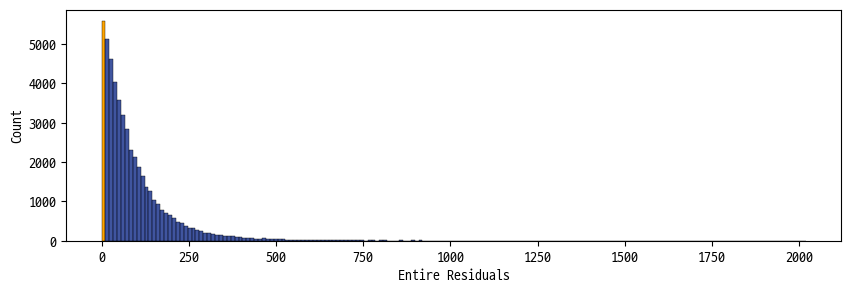

In [54]:
mean_diff = np.percentile(diff, 0.21)

# plot replicates
p = sns.histplot(diff, bins=180,kde=False)

# add the vertical line
#plt.vlines(10, 0,0.01, label='0.1%', colors="orange")

 # color bars greater than mean_diff except the partial bar
for rectangle in p.patches:
    if rectangle.get_x() <= mean_diff:
        rectangle.set_facecolor('orange')

plt.xlabel('Entire Residuals')

In [55]:
pd.DataFrame(diff.describe())

,PRSQM
count,49210.000000
mean,94.743907
std,108.819362
min,0.002029
25%,26.073839
50%,61.778802
75%,123.330011
max,2018.889399


In [56]:
diff_1p = diff[diff <= np.percentile(diff, 0.1)]

In [57]:
pd.DataFrame(diff_1p.describe())

,PRSQM
count,50.000000
mean,0.044299
std,0.025620
min,0.002029
25%,0.024356
50%,0.043542
75%,0.057393
max,0.092936


In [58]:
diff_1p_index = diff_1p.index

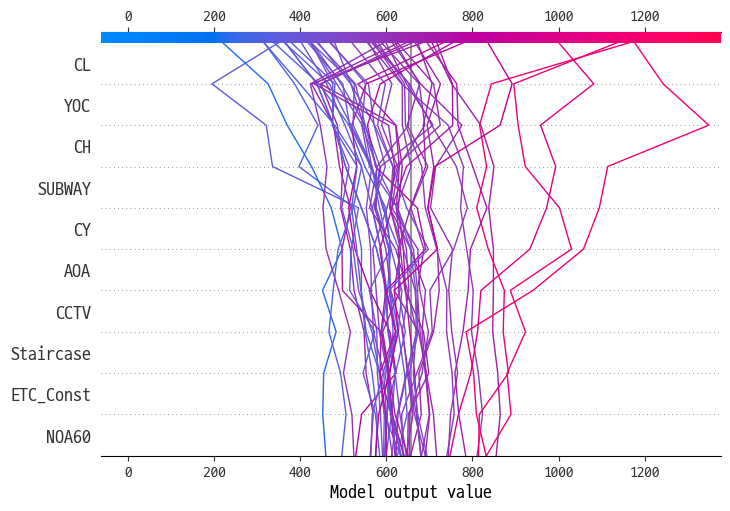

In [59]:
shap.decision_plot(base_value = explainer.expected_value, 
                   
                   shap_values = shap_values.values[diff_1p_index], 
                   
                   features = XnoNa_test.columns,
                  
                   feature_display_range=slice(None, -11, -1))

In [ ]:
# List of column names
all_columns = ['FLR', 'YOC', 'NOB', 'NOA135', 'NOA136', 'NOA60', 'NOA85', 'NOH',
               'TEAC', 'NOE', 'BUS', 'SUBWAY', 'CCTV', 'HSP', 'NOP', 'PNP', 'ELS',
               'MLS', 'HSS', 'PSC', 'NOCR', 'RHS', 'SHS', 'VHS', 'CHS', 'GH', 'CH',
               'CL', 'TP', 'PPH', 'ELD', 'AOA', 'CY', 'G3', 'DAELIM', 'DAEWOO',
               'ETC_Const', 'GS', 'HDC', 'HYUNDAI', 'Lotte', 'SAMSUNG', 'Hallway',
               'Mixed', 'Staircase', 'Tower']

# Target column names
target_columns = ['CL','YOC','CH','CY','CCTV','AOA','SUBWAY','Staircase', 'ETC_Const','PSC']

# Find the index of each target column
indices = [all_columns.index(col) for col in target_columns]

print(indices)

[27, 1, 26, 32, 12, 31, 11, 44, 36, 19]


In [146]:
indices.append(45)

In [147]:
indices

[27, 1, 26, 32, 12, 31, 11, 44, 36, 19, 45]

In [139]:
len(all_columns)

46

In [151]:
shap_values.values[diff_1p_index]

array([[-8.4258878e-01, -6.4845329e+01,  6.4142776e+00, ...,
        -2.4951584e+00, -1.6686895e+01,  1.0771061e-02],
       [ 1.2119962e+00, -6.3220301e+00,  4.4140598e+01, ...,
         2.3241343e+00,  4.3548576e+01, -7.5131664e-03],
       [ 4.6261230e+00, -1.3235412e+00, -6.2858052e+00, ...,
         5.1521319e-01,  3.0658945e+01,  3.4858648e-02],
       ...,
       [-1.4416677e+01, -4.1118481e+01,  1.7638025e+01, ...,
         3.2923095e+00,  2.7482294e+01, -4.7041830e-02],
       [ 7.0619106e+00, -7.6639977e+01, -8.9439088e-01, ...,
         8.6169596e+00,  3.4926292e+01,  2.4780678e-02],
       [-5.1459146e+00, -2.8217768e+01, -6.6225767e+00, ...,
        -4.9644706e-01, -1.0266352e+01,  2.4739972e-01]], dtype=float32)

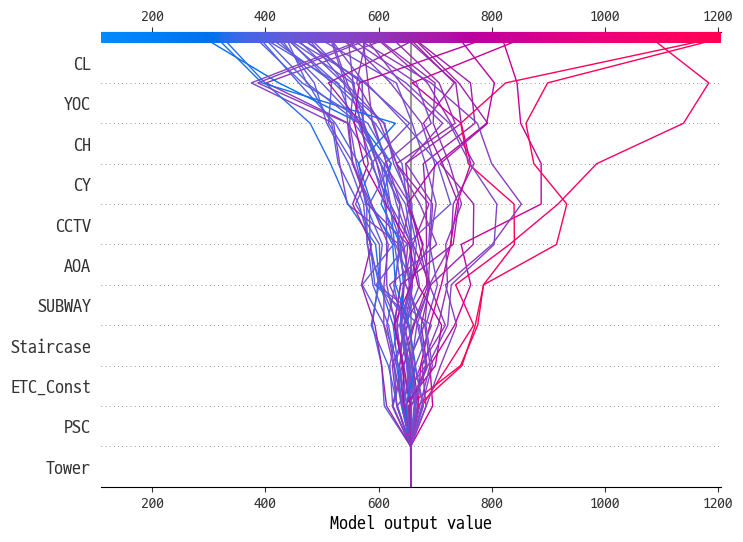

In [153]:
shap.decision_plot(base_value = explainer.expected_value, 
                   
                   shap_values = shap_values.values[diff_1p_index][:,indices], 
                   
                   features = XnoNa_test.columns[indices], 
                   
                   feature_display_range=None)

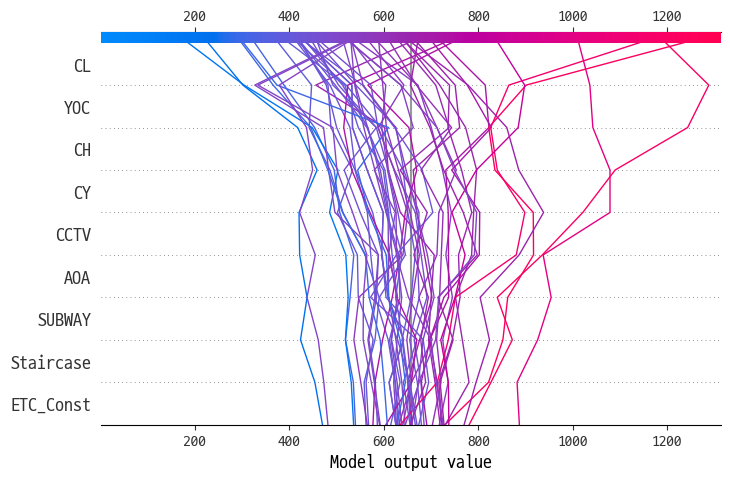

In [156]:
shap.decision_plot(base_value = explainer.expected_value, 
                   
                   shap_values = shap_values.values[diff_1p_index], 
                   
                   features = XnoNa_test.columns,
                  
                   feature_display_range=slice(None, -10, -1))

In [105]:
len(diff_1p)

491

In [106]:
len(XnoNa_test)

49070

In [42]:
shap.initjs()

In [32]:
max_instance = np.argmax(shap_values.values.sum(axis = 1))
min_instance = np.argmin(shap_values.values.sum(axis = 1))
med_instance = np.argsort(shap_values.values.sum(axis = 1))[len(shap_values.values.sum(axis = 1))//2]  #median


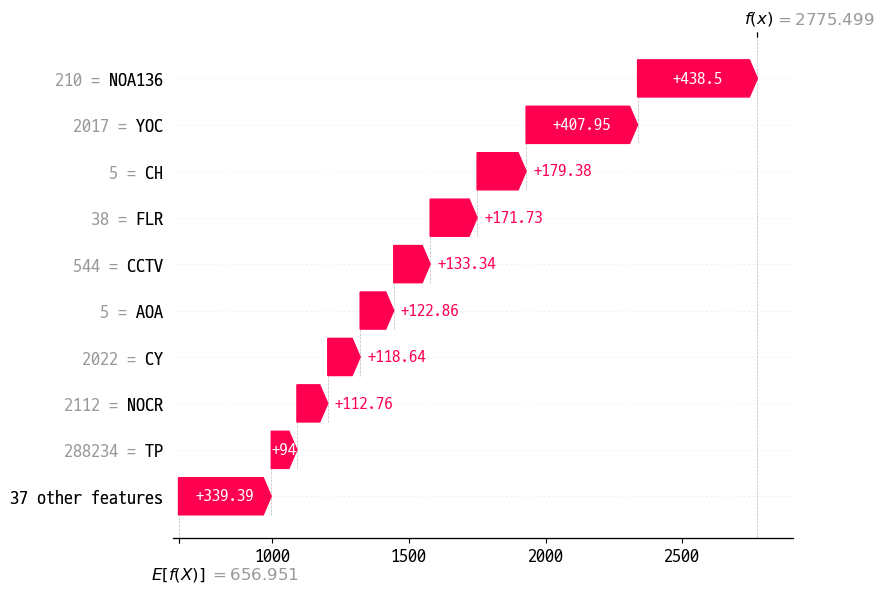

In [33]:
shap.plots.waterfall(shap_values[max_instance ])
plt.rc('axes',unicode_minus = False)

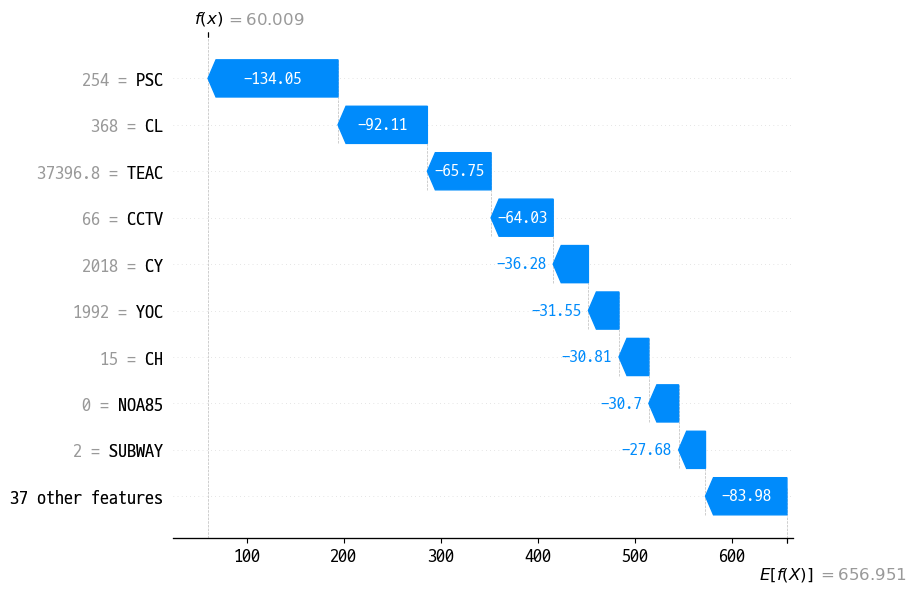

In [34]:
shap.plots.waterfall(shap_values[min_instance])

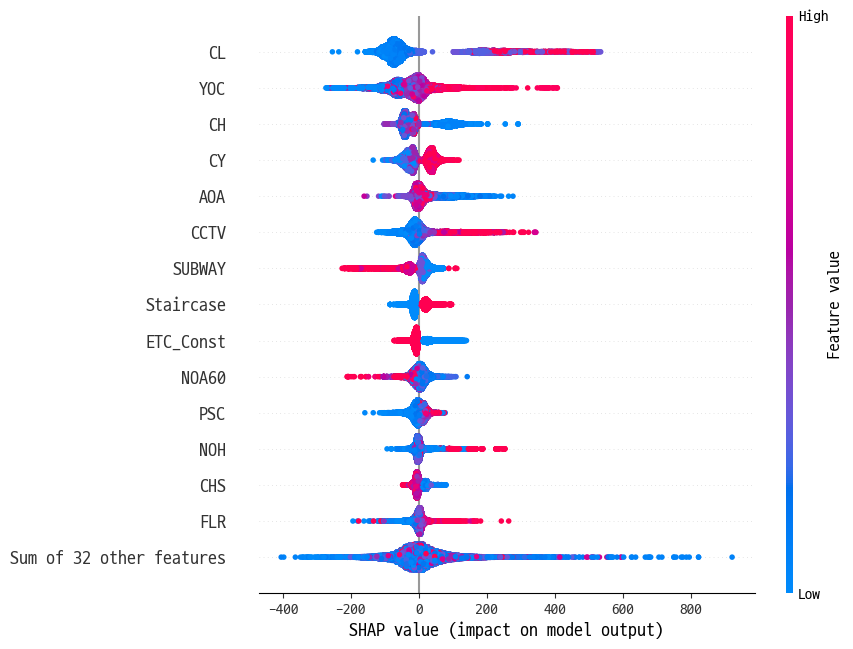

In [35]:
shap.plots.beeswarm(shap_values, max_display = 15)

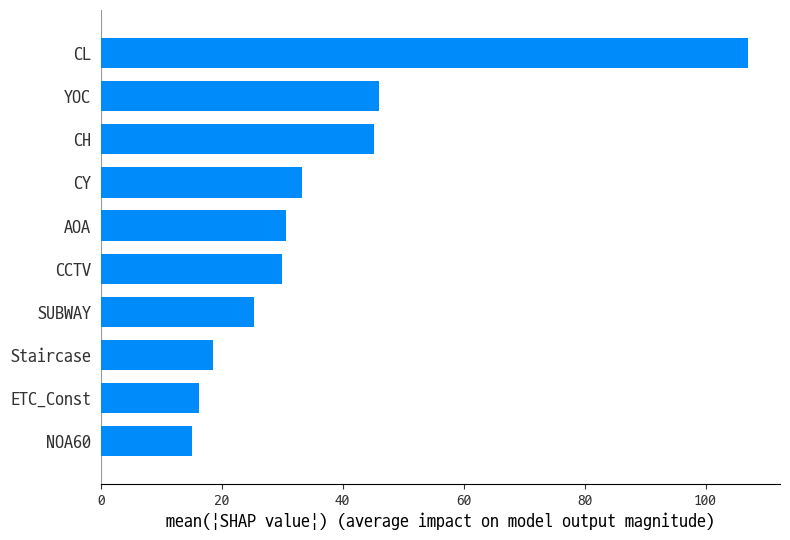

In [36]:
shap.summary_plot(shap_values,  XnoNa_test, plot_type="bar",max_display=10)

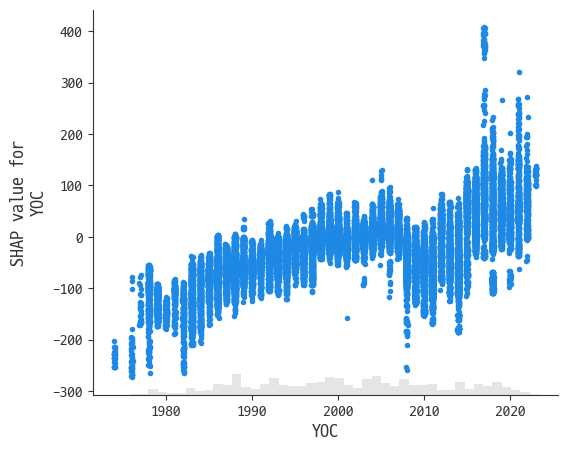

In [37]:
shap.plots.scatter(shap_values[:,"YOC"])

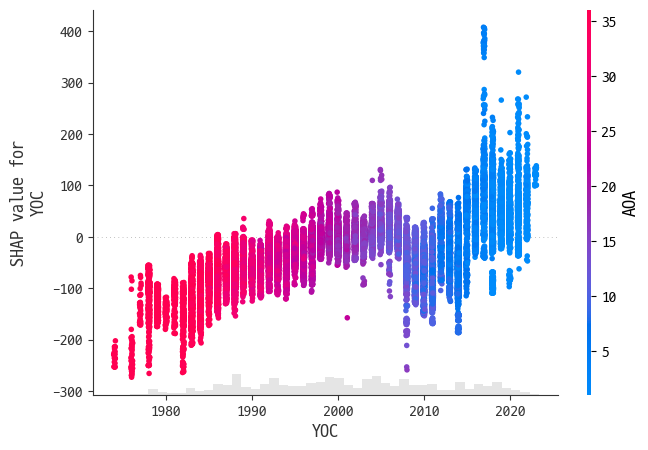

In [38]:
shap.plots.scatter(shap_values[:,"YOC"], color = shap_values[:,"AOA"])

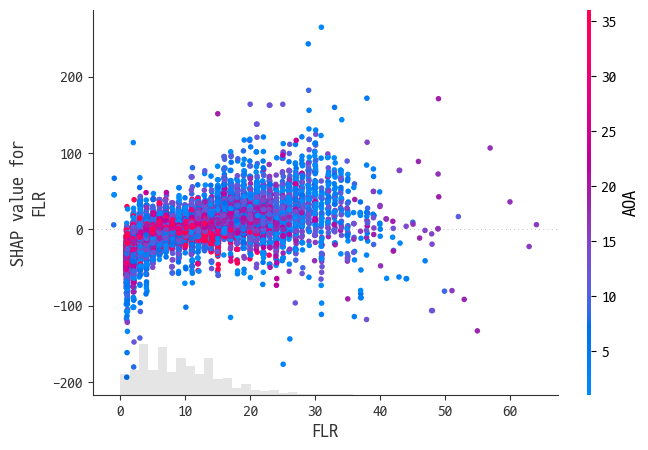

In [41]:
shap.plots.scatter(shap_values[:,"FLR"],color = shap_values[:,"AOA"])

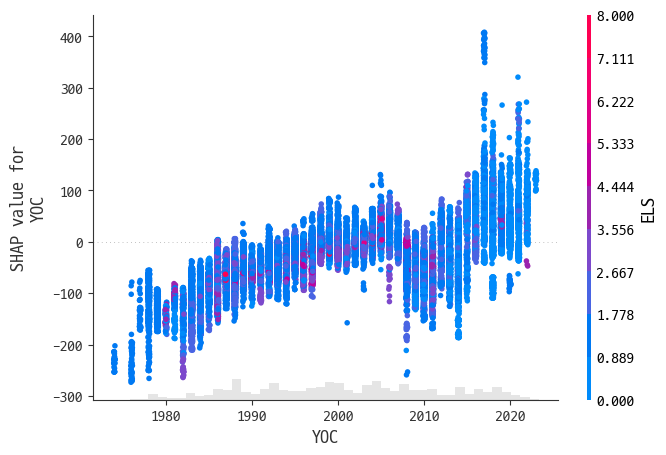

In [42]:
shap.plots.scatter(shap_values[:,"YOC"], color = shap_values[:,"ELS"])

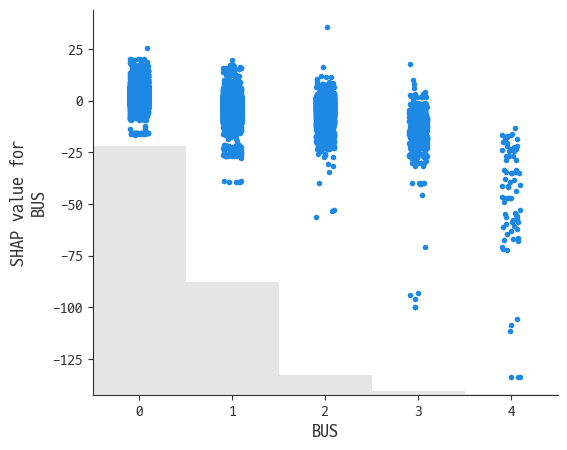

In [43]:
shap.plots.scatter(shap_values[:,"BUS"])

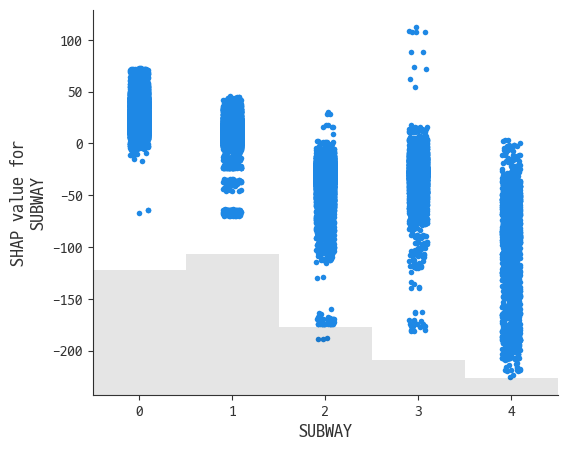

In [44]:
shap.plots.scatter(shap_values[:,"SUBWAY"])